## Node tree

- Update final on node_communities notebook
- Algo to find influential node.
- 

In [77]:
%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead 

from tes.analysis import AnalysisFunc

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm

import pandas as pd
import numpy as np
import networkx as nx
import seaborn as sns

import random  

from tes.DataUtils import DataUtils




In [78]:
reader=DataRead()
analyse=AnalysisFunc()



### Load probability averaged matrix

In [6]:

mat_avg=np.load('../../data/raw/prob_avg.npy')


### Probing probability matrix

In [39]:
p_val,counts = np.unique(mat_avg, return_counts=True)
# sorting p_val and counts in descending order
p_val=p_val[::-1]
counts=counts[::-1]
df=pd.DataFrame({'prob_val':p_val,'counts':counts})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166334 entries, 0 to 166333
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   prob_val  166334 non-null  float64
 1   counts    166334 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 2.5 MB


#### Finding probability values which have count greater than 2

In [18]:
df_2_prob=df.query("counts>1")
df_2_prob.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 844 entries, 104497 to 166333
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   prob_val  844 non-null    float64
 1   counts    844 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 19.8 KB


In [17]:
np.argwhere(mat_avg==df_2_prob['prob_val'].iloc[0])

array([[203, 297],
       [406,  56]])

(0.0, 426.0)

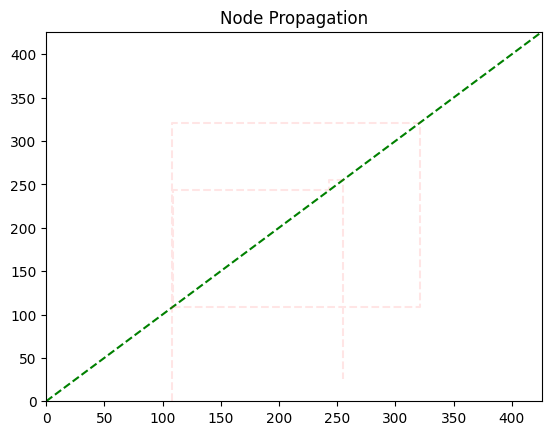

In [38]:
# checking plotting

fig,ax=plt.subplots()
x=range(0,426)
diag=ax.plot(x,x,'g--')
node_seq=ax.plot([108,108,321,321,109,109,243,243,255,255],[0,321,321,109,109,243,243,255,255,26],'r--',alpha=0.1)
ax.set_alpha(0.2)
ax.set_title('Node Propagation')
ax.set_xlim((0,426))
ax.set_ylim((0,426))


## Algorithm

1. Take a node
2. Find node pulled by it with max probability
3. Now take this node in step 2 as puller node
4. Repeat from step 1
5. 

### Defining function which search for pulled node in the PULLER NODE ROW 



In [5]:
def compute_node_tree(node,mat_avg,node_lim):
    """ returns the node tree upto
    Args: 
       node (integer): puller node
       mat_avg (2d numpy array): averaged probability matrix
       node_lim (integer): number of nodes you want in tree

    Returns: 
        list: node tree
    
    """
    node_tree=[]
    prob_values=[]
    node_tree.append(node)
    count = 0
    pdn=node
    while count<=node_lim:
    
        new_puller_node_row=mat_avg[pdn,:]
        row_sort=np.sort(new_puller_node_row)
        pn_row_des_sort=row_sort[::-1]
        
        # Finding new puller node
        pdn=np.argwhere(new_puller_node_row == pn_row_des_sort[0])[0][0]
        pdn_chk=np.argwhere(new_puller_node_row == pn_row_des_sort[0])
        if pdn_chk[0].shape[0] > 1:
            dup.append(pdn[0])

        if count !=0:
            if pdn == node_tree[-2]:
                pdn=np.argwhere(new_puller_node_row == pn_row_des_sort[1])[0][0]
                prob_values.append(pn_row_des_sort[1])
            else:
                prob_values.append(pn_row_des_sort[0])
            
        
               
        
        #new_puller_node=np.argwhere(pulled_node_row == pulled_node_row.max())[0][0]
        
        node_tree.append(pdn)
        
        count+=1
    return node_tree


    # print(f'{node_tree}')
    # print(f'{prob_values}')
    

In [125]:
nt=compute_node_tree(108,mat_avg,6)
nt
nt[0]

108

### Defining function for plotting a node tree

In [6]:
def compute_node_tree_cordinates(node_tree):
    """ Computes x and y co-ordinates for a single node tree sequence for plotting
    Args:
        node_tree (list): Node tree sequence using averaged probability matrix

    Returns:
        dictionary : co_ordinate which has keys 'x' and 'y'
        
    """
    x_nodes=[node_tree[0]]
    y_nodes=[0]
    # fig,ax=plt.subplots()
    for i,val in enumerate(node_tree):
        if i<len(node_tree)-1:
            x_nodes.append(node_tree[i])
            y_nodes.append(node_tree[i+1])
            x_nodes.append(node_tree[i+1])
            y_nodes.append(node_tree[i+1])

            # print(x_nodes)
            # print(y_nodes)
    #         x=range(0,426)
    #         diag=ax.plot(x,x,'g--')
    #         node_seq=ax.plot(x_nodes,y_nodes,'r--',alpha=0.01)
            
    # ax.set_title('Node Propagation')
    # ax.set_xlim((0,426))
    # ax.set_ylim((0,426))
        
    
    keys=['x','y']
    values=[x_nodes,y_nodes]
    co_ordinate=dict(zip(keys,values))
    return co_ordinate
    
        

In [ ]:
plot_node_tree(nt)

## Plotting for all 426 nodes


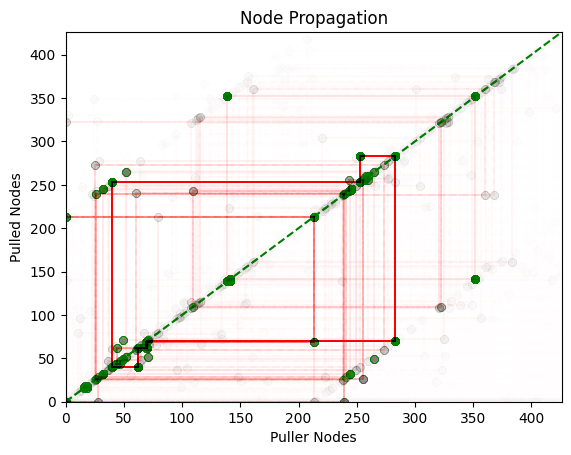

In [33]:
# import random

# def random_color():
#     return [random.random() for _ in range(3)] 
    
fig,ax=plt.subplots()
x=range(0,426)
diag=ax.plot(x,x,'g--')
for node in range(0,426):
    nt=compute_node_tree(node,mat_avg,30)
    ordinates = compute_node_tree_cordinates(nt)
    
    
    # node_seq=ax.plot(ordinates['x'],ordinates['y'],color=random_color(),linestyle='--',alpha=0.01)

    node_seq=ax.plot(ordinates['x'],ordinates['y'],'r--',alpha=0.005)
    ax.plot(ordinates['x'],ordinates['y'],'go',alpha=0.005)
    ax.set_alpha(0.2)
    ax.set_title('Node Propagation')
    ax.set_xlim((0,426))
    ax.set_ylim((0,426))
    ax.set_xlabel('Puller Nodes')
    ax.set_ylabel('Pulled Nodes')
    
    
    
    

### Checking node sequence



Text(0, 0.5, 'Pulled Nodes')

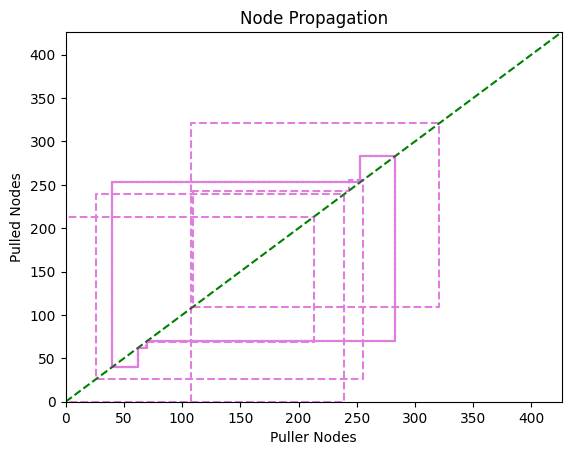

In [7]:
nt=compute_node_tree(108,mat_avg,30)
ordinates =compute_node_tree_cordinates(nt)
fig,ax=plt.subplots()
x=range(0,426)
diag=ax.plot(x,x,'g--')
# node_seq=ax.plot(ordinates['x'],ordinates['y'],color=random_color(),linestyle='--',alpha=0.01)

node_seq=ax.plot(ordinates['x'],ordinates['y'],'m--',alpha=0.5)
ax.set_alpha(0.2)
ax.set_title('Node Propagation')
ax.set_xlim((0,426))
ax.set_ylim((0,426))
ax.set_xlabel('Puller Nodes')
ax.set_ylabel('Pulled Nodes')

# pd.DataFrame({'x':ordinates['x'],'y':ordinates['y']})

#### above shows only this pattern persists to larger extent

Let's confirm this

#### Defining function to check if this sequence persists

In [8]:
def check_seq(seq):
    count=0
    seq_check=set([62,40,253,283,70])
    node_tree=set(seq)
    common=seq_check & node_tree
    if common==seq_check:
        count+=1

    return count

In [ ]:
node_diff_seq


## Finding different patterns

In [90]:
keys=[]
values=[]
for node in node_diff_seq[0:13]:
    keys.append(node)
    nt=compute_node_tree(node,mat_avg,30)
    try:
        
        pt=find_repeating_pattern(nt)
        values.append(pt)
    except ValueError: 
        print(f'Skipping invalid value: {node}')
        continue

pattern_dict=dict(zip(keys,values))

In [82]:
pattern_dict



{15: [245, 244, 32],
 16: [17, 18, 16],
 17: [18, 16, 17],
 18: [16, 17, 18],
 19: [245, 244, 32],
 20: [244, 32, 245],
 21: [18, 16, 17],
 24: [141, 139, 352],
 31: [32, 245, 244],
 32: [245, 244, 32],
 33: [17, 18, 16],
 34: [17, 18, 16]}

In [87]:
pattern_dict
len(node_diff_seq
   )
node_diff_seq[11
]

34

In [85]:
nt=compute_node_tree(49,mat_avg,30)

nt

[49,
 71,
 52,
 265,
 49,
 71,
 52,
 265,
 49,
 71,
 52,
 265,
 49,
 71,
 52,
 265,
 49,
 71,
 52,
 265,
 49,
 71,
 52,
 265,
 49,
 71,
 52,
 265,
 49,
 71,
 52,
 265]

#### Finding count of how much times this sequence repeats and for which starting nodes it does not

In [65]:
def find_repeating_pattern(node_tree):
    """ Returns 3 element repeating pattern if any after taking input a node tree
    Args:
        node_tree (list): node sequence computed from probability average matrix 
    Returns:
        list which has repeating sequence if any
    """
    pattern=[]
    for node in node_tree:
        #temp seq to check for repeating node
        temp=node_tree
        temp.remove(node)
        if check_node_repeat(temp,node)==1: 
            pattern=find_pattern(node_tree,node)
            
        else:
            continue


    return pattern
    

In [68]:
nt=compute_node_tree(108,mat_avg,50)
print(find_repeating_pattern(nt))



[62, 40, 253]


In [63]:

def check_node_repeat(node_seq,n):
    """ Takes node sequence and node to be checked in given sequence
    Args:
        node_seq (list): node tree with that node removed wwhich is to be checked for presence in the given sequence 
        n (integer): the node to be checked  

    Returns: 
        integer: it returns 1 if the node is present in given sequence
    
    """
    c=0
    if n in node_seq:
        c+=1

    return c

In [64]:
def find_pattern(node_seq,node):
    """ Takes node tree and the node that repeats and returns the pattern upto 3 elements 
    Args: 
        node_seq (list): node tree which comes from avg prob matrix
        node (integer): node from which pattern starts

    Returns: 
        list: pattern containing 3 elements
     
    """
    nt=np.array(node_seq)
    ind=np.argwhere(nt==node)


    #check patterns 
    pattern1=[]
    pattern2=[]

    p1_start_ind = ind[0][0]
    p2_start_ind = ind[1][0]

    pattern1.append(node_seq[p1_start_ind])
    pattern1.append(node_seq[p1_start_ind+1])
    pattern1.append(node_seq[p1_start_ind+2])


    pattern2.append(node_seq[p2_start_ind])
    pattern2.append(node_seq[p2_start_ind+1])
    pattern2.append(node_seq[p2_start_ind+2])

    if pattern1==pattern2:
        return pattern1
    
    

#### Finding pattern if any for other sequences


In [62]:
nt=compute_node_tree(108,mat_avg,30)
# nt.remove(62)
# n=62
# c=0

# p=check_node_repeat(nt,62)
# print(p)

indices=find_pattern(nt,108)
print(indices)

IndexError: index 1 is out of bounds for axis 0 with size 1

In [59]:
indices[1
][0
]

15

#### Let's plot for nodes which have different sequence 

This is to be checked  
Close, can do it  
Check also node tree algo


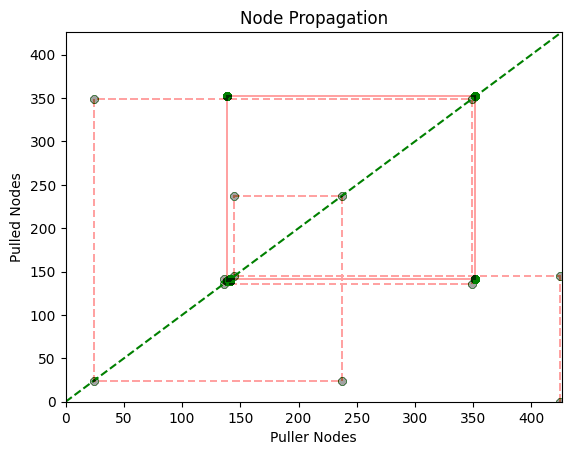

In [35]:
# len(node_diff_seq)+333
fig,ax=plt.subplots()
x=range(0,426)
diag=ax.plot(x,x,'g--')
for nodes in node_diff_seq: 
    
    nt=compute_node_tree(nodes,mat_avg,30)
    ord=compute_node_tree_cordinates(nt)

    ax.plot(ordinates['x'],ordinates['y'],'r--',alpha=0.005)

    ax.plot(ordinates['x'],ordinates['y'],'go',alpha=0.005)
    ax.set_alpha(0.2)
    ax.set_title('Node Propagation')
    ax.set_xlim((0,426))
    ax.set_ylim((0,426))
    ax.set_xlabel('Puller Nodes')
    ax.set_ylabel('Pulled Nodes')

    

### To plot for any given sequence

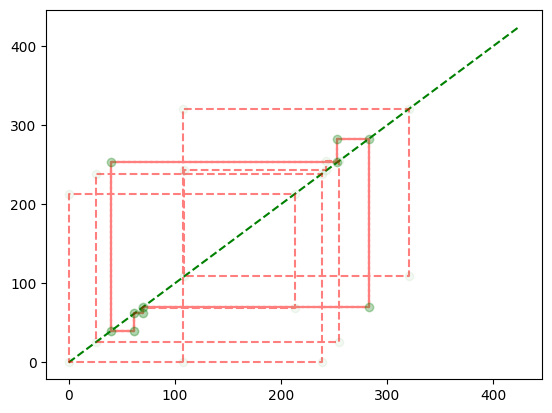

In [31]:
nt=compute_node_tree(108,mat_avg,40)
ordinates = compute_node_tree_cordinates(nt)


fig,ax=plt.subplots()
x=range(0,426)
diag=ax.plot(x,x,'g--')

ax.plot(ordinates['x'],ordinates['y'],'r--',alpha=0.5)
ax.plot(ordinates['x'],ordinates['y'],'go',alpha=0.05)
fig.show()

### Finding repeating sequence in the given sequence

Algorithm:  
1. Find the node which repeats
2. Check for next 2 consecutive nodes
3. If above pattern exists, then consider it as a pattern 

# Algo to find sync cluster


In [37]:
test_case=[[71],
 [52],
 [50, 52, 71],
 [50, 52, 71, 263],
 [50, 52, 71, 263, 265],
 [50, 52, 71, 263, 265, 284],
 [52, 71, 263, 265, 284],
 [52, 265],
 [38],
 [38,57]]

test_case


[[71],
 [52],
 [50, 52, 71],
 [50, 52, 71, 263],
 [50, 52, 71, 263, 265],
 [50, 52, 71, 263, 265, 284],
 [52, 71, 263, 265, 284],
 [52, 265],
 [38],
 [38, 57]]

In [35]:
test_case=[[1,100,3],
[1,100,58],
[1,100],
[50],[50,67,78]]



In [34]:
test_case=[[71,200],[52,300,400]] # Checking If all old nodes gets removed, new node set comes, start afresh
test_case=[[71,200],[52,300,400],[52,400],[52,250]]







In [60]:
df_nc = reader.data_read_bz2('raw/FN/nc_200.bz2')
nl=analyse.node_count(df_nc.loc[2])
node_list=nl['node_list']





### Algorithm

1. Draw the diagonal of 426 x 426 matrix
2. Take consecutive timesteps one by one
3. If there is addition of new node and starting fresh, add (old_node,0) & (old_node,added_node)
5. Move to diagonal with all current node pairs (current_node,current_node)
6. Observe next time step:
   - If new nodes added with old ones (drop old ones which does not remain) remaining, move to old ones from diagonal (diag,diag) to (diag,added_node)
   - repeat step 4 and 5
   -  If no new nodes added or some old nodes gets dropped, drop hose points from diagonal
   -  If complete new set of nodes appear, start fresh i.e step 3



In [75]:
def plot_common_nodes(node_set): 
    b=0.002
    i=0
    plot_data=[]
    fig,ax = plt.subplots(figsize=(12,8))
    d=range(0,426)
    ax.plot(d,d,'m--')
    while i+1<len(node_set): 
        # getting two consecutive row sets
        
        r1=node_set[i]
        r2=node_set[i+1]
        s1=set(r1)
        s2=set(r2)

        set_union=s1.union(s2)
        set_common=s1.intersection(s2)
        set_diff_1=s1-s2
        set_diff=s2-s1
        #print(f'The set difference for {r1} and {r2} is {set_diff}')

        # using if-elif to check

        # Checking If all old nodes gets removed, new node set comes, start afresh
        if not set_common:
            x=[]
            y=[]
            for n in r1:
                for m in r2:
                    x=[n]*2
                    x.append(m)
                    y=[m]*2
                    y.insert(0,0)
                    
                    #print(f'The co ordinates are {x} and {y} for rows {r1} and {r2}')
                
                    plt.plot(x,y,'r-',alpha=b)
                    #plt.plot(x,y,'cx',alpha=0.05)

                x=[] 
                y=[]
                

        # check if a node drops and no new node added, do nothing
        elif set_union==s1: 
            # for n in set_diff_1:  
            #     x.remove(n)
            #     y.remove(n)

            # ax.plot(x,y,'go',alpha=0.05)
            pass            

        # checking if a new node adds (whether some old nodes remain or gets dropped), add a point (old nodes (current), new node)
        else:
            x=[] 
            y=[]  
            for n in set_common:
                for m in set_diff:
                    x=[n]*2
                    x.append(m)
                    y=[m]*2
                    y.insert(0,n)
                    
                    #print(f'The co-ordinates are {x},{y} for {r1} and {r2}')
               
                    plt.plot(x,y,'r-',alpha=b)
                    #plt.plot(x,y,'yo',alpha=0.05)
                x=[]
                y=[]

        i+=1  
    plt.xlabel('nodes')
    plt.ylabel('nodes')
    plt.title(f'Plot for node propagation {b}')            
    plt.savefig('../../data/results/node_tree.png')











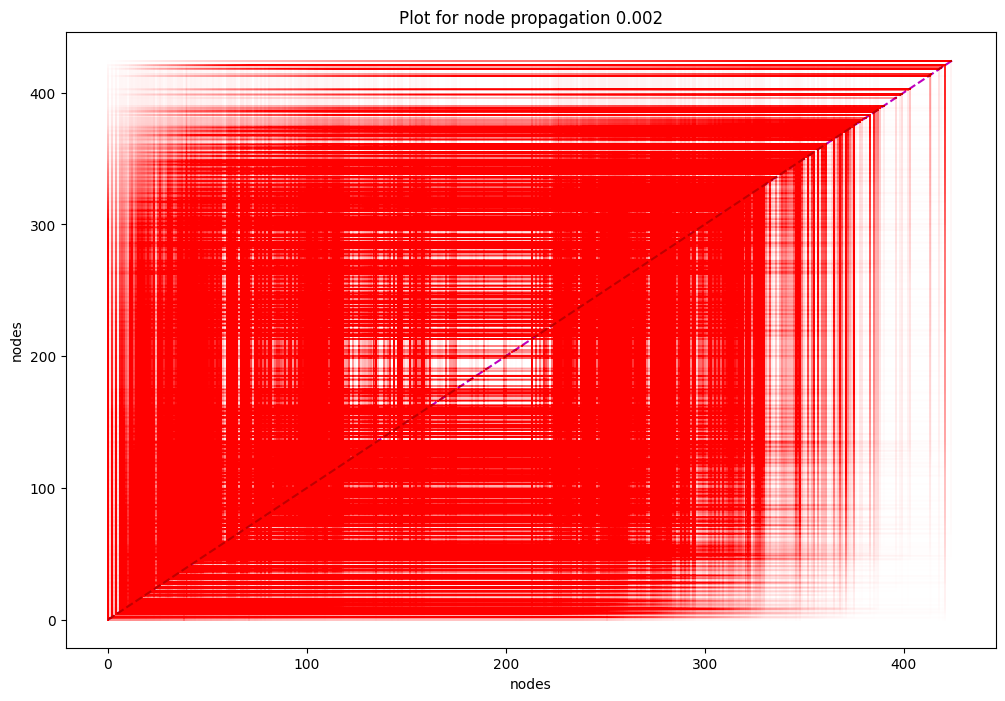

In [76]:
plot_common_nodes(node_list)




In [7]:
s={1,2,3}
g={1,2,4}
c=g-s
c




{4}

####  Let's write some rules 

- If a new node adds (whether some old nodes remain or gets dropped), add a point (old nodes (current), new node)
- If a node drops and no new node added, do nothing
- If all old nodes gets removed, new node set comes, start afresh
- 

In [37]:
def plot_common_nodes(node_set): 
    i=0
    plot_data=[]
    while i+1<len(node_set): 
        # getting two consecutive row sets
        r1=node_set[i]
        r2=node_set[i+1]
        s1=set(r1)
        s2=set(r2)

        set_union=s1.union(s2)
        set_common=s1.intersection(s2)
        set_diff=s2-s1
        #print(f'The set difference for {r1} and {r2} is {set_diff}')

        # using if-elif to check

        # Checking If all old nodes gets removed, new node set comes, start afresh
        if not set_common: 
            pass

        # checking If a node drops and no new node added, do nothing
        elif set_union==s1: 
            pass

        # checking if a new node adds (whether some old nodes remain or gets dropped), add a point (old nodes (current), new node)
        else:
            x=[]
            y=[]
            for node in r1:
                x=[node]*(len(set_diff)+1)
                y=list(set_diff)
                y.insert(0,0)

                print(f'The co-ordinates are {x},{y} for {r1} and {r2}')
               
                plt.plot(x,y,'r-',alpha=0.05)
                plt.plot(x,y,'go',alpha=0.05)
                x=[]
                y=[]

        i+=1  
    plt.xlabel('nodes')
    plt.ylabel('nodes')
    plt.title('Plot for node propagation')            
            
            
    

The co-ordinates are [52, 52, 52],[0, 50, 71] for [52] and [50, 52, 71]
The co-ordinates are [50, 50],[0, 263] for [50, 52, 71] and [50, 52, 71, 263]
The co-ordinates are [52, 52],[0, 263] for [50, 52, 71] and [50, 52, 71, 263]
The co-ordinates are [71, 71],[0, 263] for [50, 52, 71] and [50, 52, 71, 263]
The co-ordinates are [50, 50],[0, 265] for [50, 52, 71, 263] and [50, 52, 71, 263, 265]
The co-ordinates are [52, 52],[0, 265] for [50, 52, 71, 263] and [50, 52, 71, 263, 265]
The co-ordinates are [71, 71],[0, 265] for [50, 52, 71, 263] and [50, 52, 71, 263, 265]
The co-ordinates are [263, 263],[0, 265] for [50, 52, 71, 263] and [50, 52, 71, 263, 265]
The co-ordinates are [50, 50],[0, 284] for [50, 52, 71, 263, 265] and [50, 52, 71, 263, 265, 284]
The co-ordinates are [52, 52],[0, 284] for [50, 52, 71, 263, 265] and [50, 52, 71, 263, 265, 284]
The co-ordinates are [71, 71],[0, 284] for [50, 52, 71, 263, 265] and [50, 52, 71, 263, 265, 284]
The co-ordinates are [263, 263],[0, 284] for [

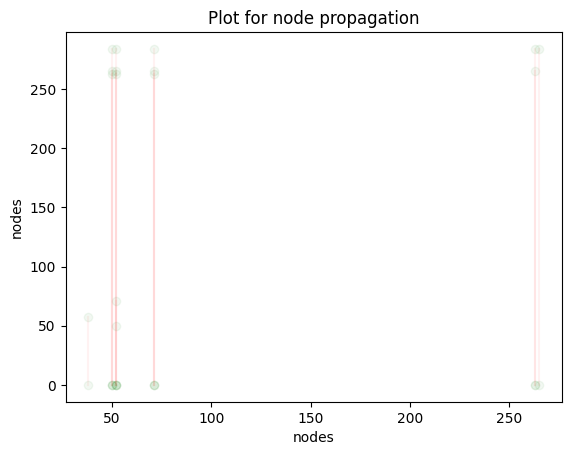

In [38]:
plot_common_nodes(test_case)

In [36]:
set_diff


NameError: name 'set_diff' is not defined